In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_ne_by_design import NE_LPN_By_Design
from utils import prox, cvx, prior, gt_cvx, prox_gaussian

sns.set()

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

np.random.seed(1)
torch.manual_seed(1)

In [2]:
class NormalSampler:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, n):
        return torch.randn(n) * self.std + self.mean

def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

def exp_func(x, gamma):
    return -torch.exp(-((x / gamma) ** 2)) + 1

In [3]:
def single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss=None):
    target = sampler(bsize).unsqueeze(1).to(device)
    input_ = add_noise(target, sigma_noise).to(device)
    output = model(input_)

    if loss_type == 2:
        loss = torch.nn.functional.mse_loss(output, target)
    elif loss_type == 1:
        loss = torch.nn.functional.l1_loss(output, target)
    elif loss_type == 0:
        loss = exp_func(output - target, gamma_loss).mean()
    else:
        raise ValueError("Invalid loss_type")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if hasattr(model, "wclip"):
        model.wclip()
    return loss.item()


In [4]:
def plot_all(model, title):
    xi = np.linspace(-4, 4, 1000)
    y = prox(xi, model)
    c = cvx(xi, model)
    p = prior(xi, model)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].plot(xi, y, label="LPN")
    axs[0].plot(xi, prox_gaussian(xi), '--', label="soft thr.")
    axs[0].set_title("Learned prox")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(xi, c - c.min(), label="Cvx func")
    axs[1].plot(xi, gt_cvx(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(xi, p - p.min(), label="LPN")
    axs[2].plot(xi, 0.5 * xi**2, '--', label=r"$\frac{1}{2}x^2$")
    axs[2].set_title("Original func")
    axs[2].grid(True)
    axs[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_plot.png"))
    plt.show()

In [5]:
def plot_comparison(models):
    xi = np.linspace(-4, 4, 1000)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    for name, model in models.items():
        y = prox(xi, model)
        c = cvx(xi, model)
        p = prior(xi, model)

        axs[0].plot(xi, y, label=name)
        axs[1].plot(xi, c - c.min(), label=name)
        axs[2].plot(xi, p - p.min(), label=name)

    axs[0].plot(xi, prox_gaussian(xi), '--', label="gaussian prox")
    axs[0].set_title("Learned prox")
    axs[1].plot(xi, gt_cvx(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[2].plot(xi, 0.5 * xi**2, '--', label=r"$\frac{1}{2}x^2$")
    axs[2].set_title("Original func")

    for ax in axs:
        ax.grid(True)
        ax.legend()

    plt.suptitle("Model Comparison")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "model_comparison.png"))
    plt.show()
    

In [6]:
def train_model(model, model_name, loss_type, gamma_loss, sampler, sigma_noise, 
                lr_schedule, iterations_per_phase):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
    bsize = 2000
    loss_log = []

    print(f"Training {model_name}...")
    for phase, lr in enumerate(lr_schedule):
        for g in optimizer.param_groups:
            g['lr'] = lr
        for i in range(iterations_per_phase):
            loss = single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss)
            if i % 100 == 0:
                print(f"{model_name} | Phase {phase+1}/{len(lr_schedule)} | Iter {i}: Loss = {loss:.6f}")
                loss_log.append(loss)

    # Save and plot
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    plot_all(model, title=model_name)
    return model
    

In [ ]:
sampler = NormalSampler()
sigma_noise = 1.0
loss_type = 0  # Proximal matching loss
gamma_loss = 0.1
lr_schedule = [1e-3, 1e-4]  # mimic original notebook
iterations_per_phase = 10000

In [8]:
dim = 1
hidden = 50
layers = 4
beta = 10

In [9]:
def get_models():
    return {
        "Original_LPN": LPN(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Norm": NE_LPN_By_Norm(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Design": NE_LPN_By_Design(in_dim=dim, hidden=hidden, layers=layers, beta=beta)
    }

Training Original_LPN...
Original_LPN | Phase 1/2 | Iter 0: Loss = 0.683074
Original_LPN | Phase 1/2 | Iter 100: Loss = 0.551514
Original_LPN | Phase 1/2 | Iter 200: Loss = 0.562241
Original_LPN | Phase 1/2 | Iter 300: Loss = 0.541269
Original_LPN | Phase 1/2 | Iter 400: Loss = 0.551256
Original_LPN | Phase 1/2 | Iter 500: Loss = 0.559707
Original_LPN | Phase 1/2 | Iter 600: Loss = 0.547144
Original_LPN | Phase 1/2 | Iter 700: Loss = 0.550508
Original_LPN | Phase 1/2 | Iter 800: Loss = 0.560974
Original_LPN | Phase 1/2 | Iter 900: Loss = 0.562562
Original_LPN | Phase 1/2 | Iter 1000: Loss = 0.554938
Original_LPN | Phase 1/2 | Iter 1100: Loss = 0.550058
Original_LPN | Phase 1/2 | Iter 1200: Loss = 0.554606
Original_LPN | Phase 1/2 | Iter 1300: Loss = 0.551493
Original_LPN | Phase 1/2 | Iter 1400: Loss = 0.548722
Original_LPN | Phase 1/2 | Iter 1500: Loss = 0.554665
Original_LPN | Phase 1/2 | Iter 1600: Loss = 0.555700
Original_LPN | Phase 1/2 | Iter 1700: Loss = 0.557206
Original_LPN | 

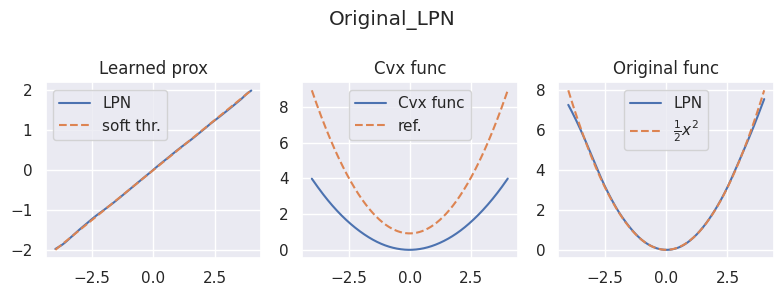

Training NE_By_Norm...
NE_By_Norm | Phase 1/2 | Iter 0: Loss = 0.713840
NE_By_Norm | Phase 1/2 | Iter 100: Loss = 0.560643
NE_By_Norm | Phase 1/2 | Iter 200: Loss = 0.560261
NE_By_Norm | Phase 1/2 | Iter 300: Loss = 0.554824
NE_By_Norm | Phase 1/2 | Iter 400: Loss = 0.561641
NE_By_Norm | Phase 1/2 | Iter 500: Loss = 0.573130
NE_By_Norm | Phase 1/2 | Iter 600: Loss = 0.544742
NE_By_Norm | Phase 1/2 | Iter 700: Loss = 0.550353
NE_By_Norm | Phase 1/2 | Iter 800: Loss = 0.557950
NE_By_Norm | Phase 1/2 | Iter 900: Loss = 0.543843
NE_By_Norm | Phase 1/2 | Iter 1000: Loss = 0.560807
NE_By_Norm | Phase 1/2 | Iter 1100: Loss = 0.552843
NE_By_Norm | Phase 1/2 | Iter 1200: Loss = 0.550759
NE_By_Norm | Phase 1/2 | Iter 1300: Loss = 0.551134
NE_By_Norm | Phase 1/2 | Iter 1400: Loss = 0.545111
NE_By_Norm | Phase 1/2 | Iter 1500: Loss = 0.560001
NE_By_Norm | Phase 1/2 | Iter 1600: Loss = 0.545343
NE_By_Norm | Phase 1/2 | Iter 1700: Loss = 0.551006
NE_By_Norm | Phase 1/2 | Iter 1800: Loss = 0.554033
N

In [ ]:
trained_models = {}
for name, model in get_models().items():
    trained_models[name] = train_model(model, name, loss_type, gamma_loss, 
                                       sampler=sampler, sigma_noise=sigma_noise, 
                                       lr_schedule=lr_schedule, iterations_per_phase=iterations_per_phase)

plot_comparison(trained_models)
print("All models trained and plotted.")